In [13]:
from pathlib import Path

from prismadv.data_models import Constraints
from workflow_prismadv.utils.results_analysis import build_confusion_matrices
from workflow_prismadv.utils.results_analysis import collect_results
from workflow_prismadv.utils.results_analysis import format_results_latex

In [14]:
dataset_name_options = ["students", "hr_analytics", "sleep_health", "IPL_win_prediction", "imdb"]
model_order = ["gemini-2.5-flash", "gpt-4.1", "gpt-4o", "gpt-5-mini", "gemini-2.5-pro", "gpt-5"]
unique_subset_cols = [
    "llm_name", "llm_temperature",
    "dataset_name", "subtask_name",
    "processed_data_label", "script_name", "is_clean"
]

In [15]:
def meta_extractor_few_shot(constraint_file: Path, raw: dict) -> dict:
    parts = constraint_file.stem.split("--")
    llm_name = parts[1] if len(parts) > 1 else "unknown"
    return {
        "llm_name": llm_name,
        "llm_temperature": 0.6,
        "timestamp": constraint_file.stem.split("--")[-1],
    }


def constraints_parser_few_shot(raw: dict):
    return Constraints.from_dict({"constraints": raw["constraints"]})


df_all_unique = collect_results(
    dataset_name_options=dataset_name_options,
    unique_subset_cols=unique_subset_cols,
    constraint_glob="few_shot*.yaml",
    row_meta_extractor=meta_extractor_few_shot,
    constraints_parser=constraints_parser_few_shot,
    model_order=model_order,  # optional filter
)

In [16]:
confusion_matrices_df = build_confusion_matrices(df_all_unique)

In [17]:
latex_output = format_results_latex(
    confusion_matrex_df=confusion_matrices_df,
    dataset_name_options=dataset_name_options,
    model_order=model_order,
    decimals=1,
    model_label_prefix="few-shot",
    include_overall=True
)
print(latex_output)

%% === Dataset: students ===
& \texttt{few-shot [gemini-2.5-flash]} & 64.6 & 6.2 & 0 & 131 & 119 & 0 & - & 0.0\% & - \\
& \texttt{few-shot [gpt-4.1]} & 34.3 & 5.1 & 0 & 131 & 119 & 0 & - & 0.0\% & - \\
& \texttt{few-shot [gpt-4o]} & 19.1 & 1.2 & 52 & 79 & 89 & 30 & 63.4\% & 39.7\% & 48.8\% \\
& \texttt{few-shot [gpt-5-mini]} & 28.6 & 7.6 & 0 & 131 & 119 & 0 & - & 0.0\% & - \\
& \texttt{few-shot [gemini-2.5-pro]} & 11.3 & 1.2 & 0 & 131 & 119 & 0 & - & 0.0\% & - \\
& \texttt{few-shot [gpt-5]} & 38.5 & 3.9 & 0 & 131 & 119 & 0 & - & 0.0\% & - \\
%% === Dataset: hr_analytics ===
& \texttt{few-shot [gemini-2.5-flash]} & 40.8 & 9.8 & 75 & 92 & 114 & 19 & 79.8\% & 44.9\% & 57.5\% \\
& \texttt{few-shot [gpt-4.1]} & 22.9 & 5.2 & 91 & 76 & 108 & 25 & 78.4\% & 54.5\% & 64.3\% \\
& \texttt{few-shot [gpt-4o]} & 15.0 & 1.8 & 44 & 123 & 132 & 1 & 97.8\% & 26.3\% & 41.5\% \\
& \texttt{few-shot [gpt-5-mini]} & 21.0 & 1.8 & 95 & 72 & 102 & 31 & 75.4\% & 56.9\% & 64.8\% \\
& \texttt{few-shot [gemini-2.5-p

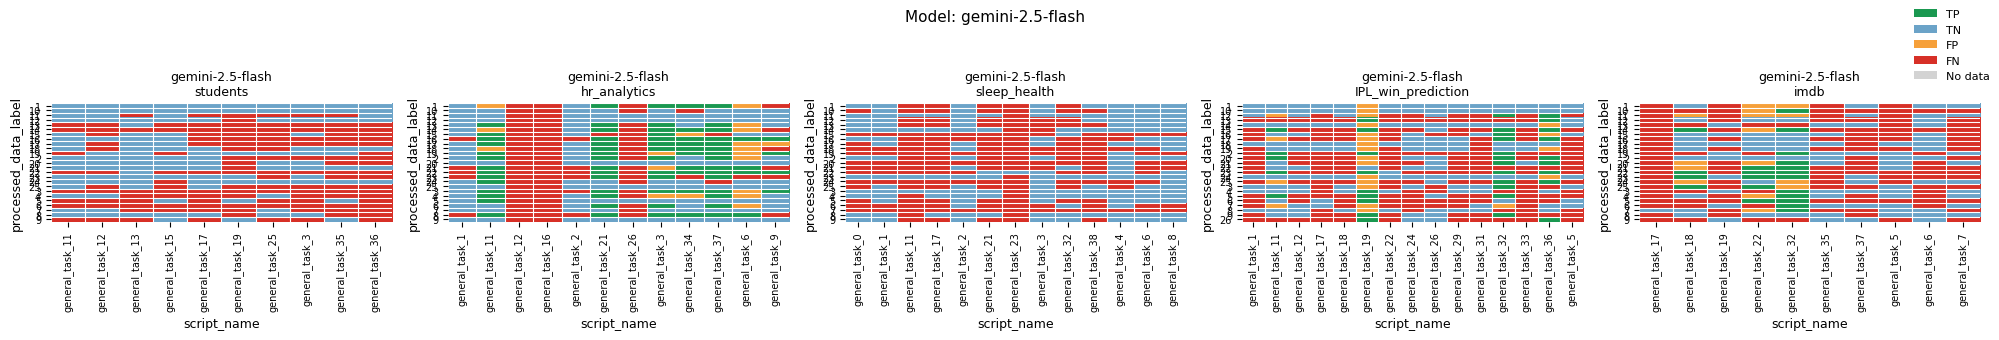

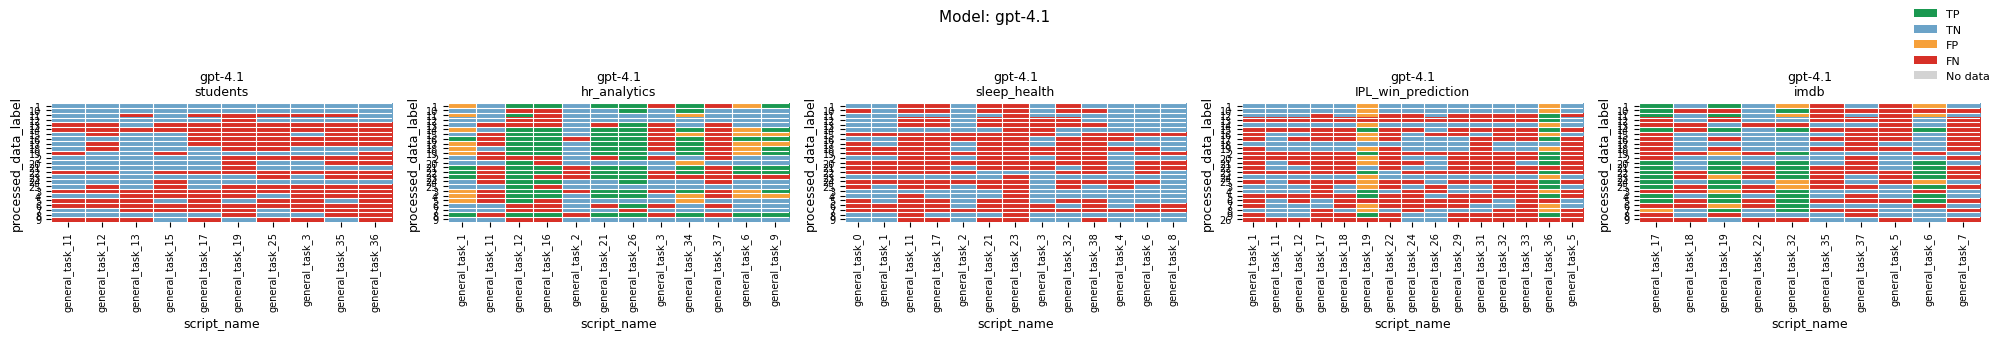

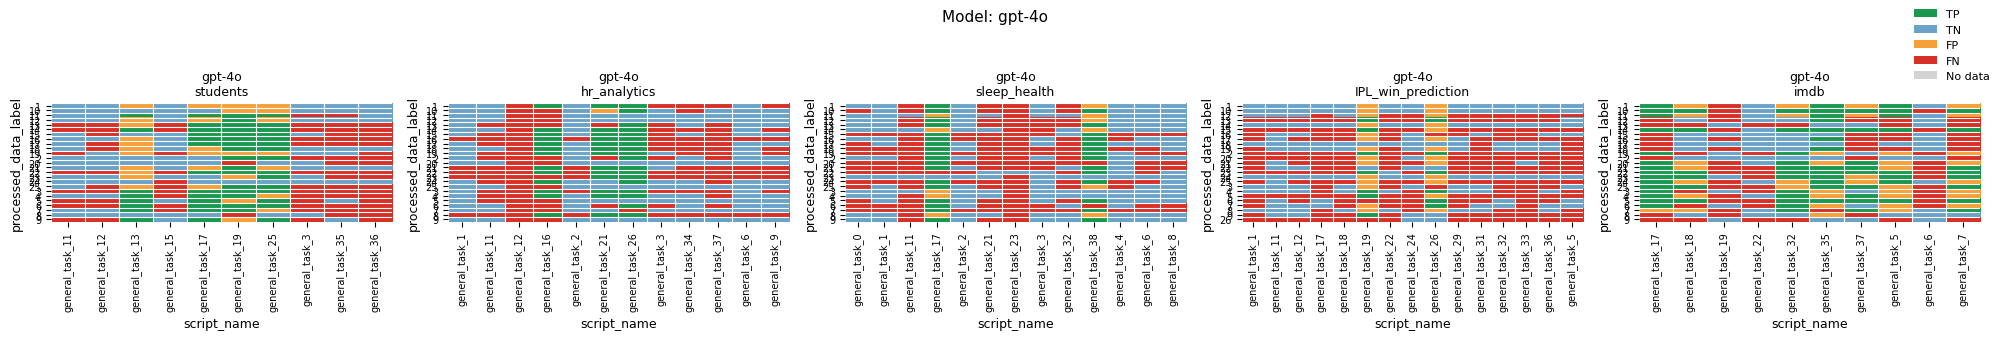

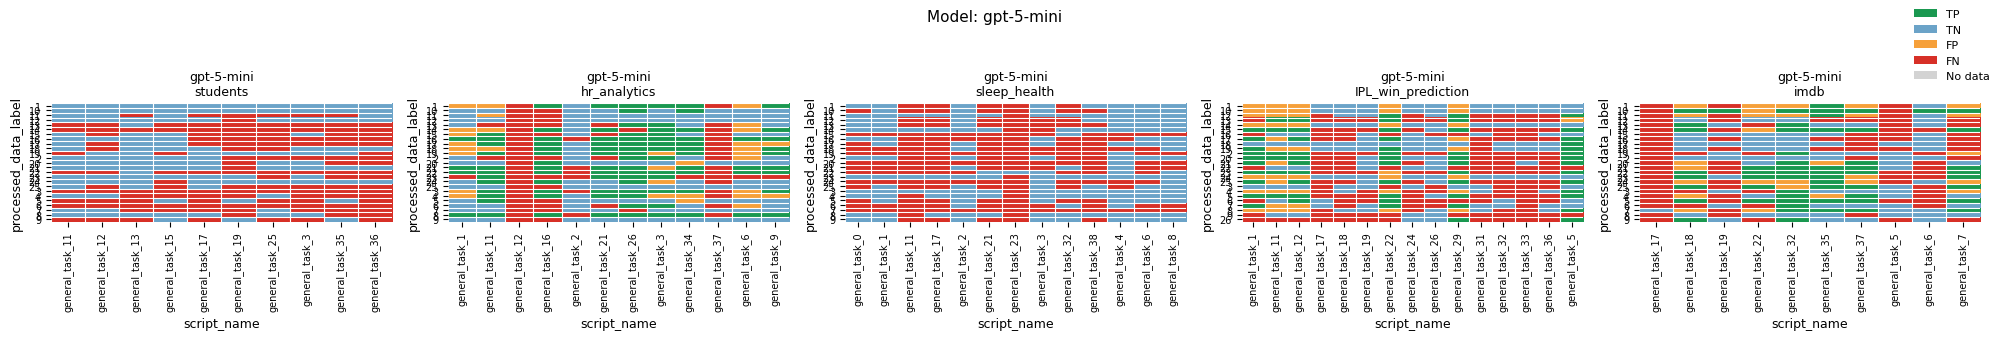

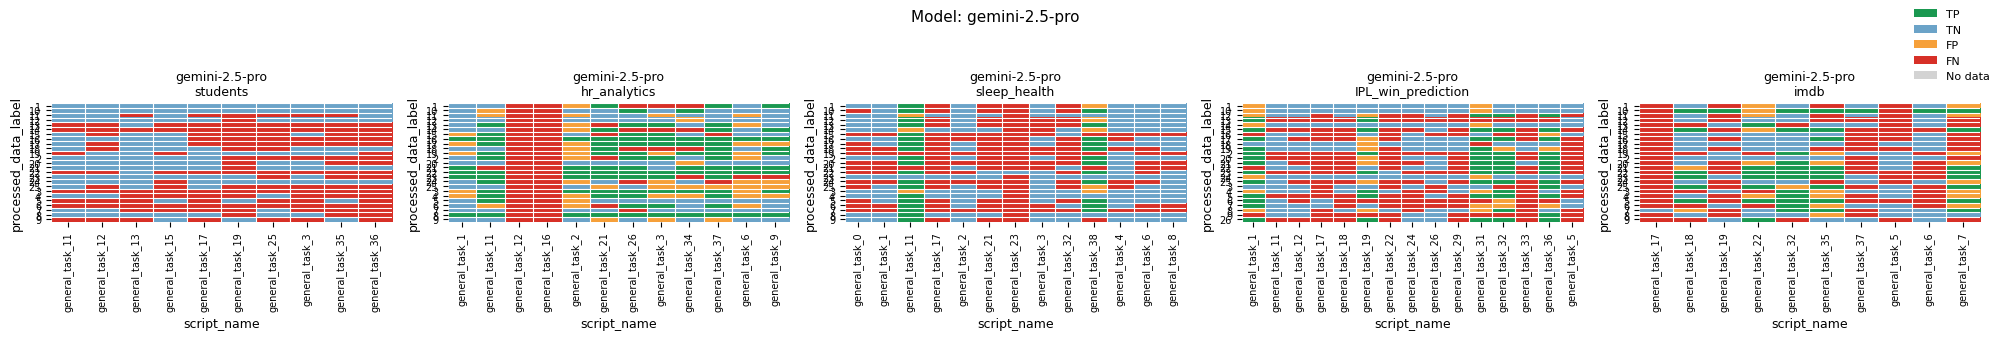

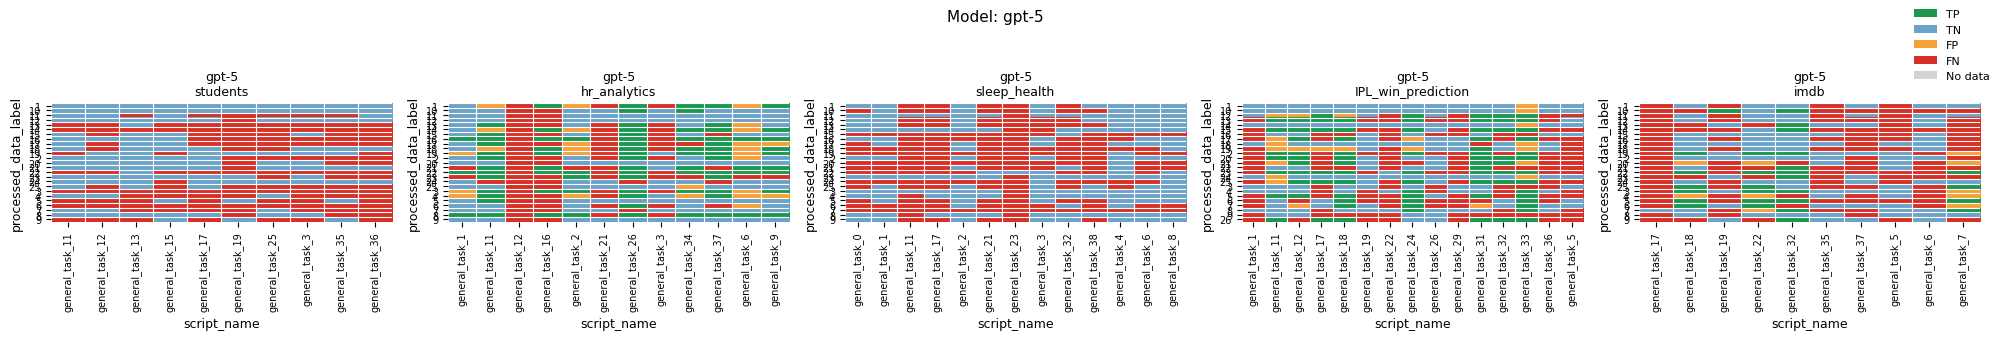

In [18]:
from workflow_prismadv.utils.results_analysis import build_correct_grids, plot_correct_grids

grids = build_correct_grids(df_all_unique, dataset_name_options, threshold=0.5)
plot_correct_grids(grids, model_order=model_order, dataset_name_options=dataset_name_options)